# Task 14 — Binary Image Classification Using a Convolutional Neural Network

## Mini Project: Neural Network Implementation with Documented Design Choices

### Objective

Build a Convolutional Neural Network (CNN) to classify casting product images into two categories:

- **Class 0 → Non-defective (`ok_front`)**
- **Class 1 → Defective (`def_front`)**

This notebook implements the complete CNN pipeline including:

- Dataset loading
- Data preprocessing
- Data augmentation
- CNN architecture
- Model training
- Validation
- Evaluation
- Confusion matrix
- Precision and Recall
- Five unseen-image predictions
- Design decision documentation
- Model saving


---

# CELL 3 — Markdown

```markdown
## 1. Dataset Description

The dataset used is the **Casting Product Image Data for Quality Inspection** dataset.

The dataset contains images of manufactured casting products.

The classification problem is binary:

| Folder | Meaning | Class |
|---|---|---:|
| `ok_front` | Non-defective | 0 |
| `def_front` | Defective | 1 |

The objective is to automatically identify whether a casting product is defective or non-defective.

In [1]:
# Import required libraries

from pathlib import Path
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.5.2


In [2]:
# Set random seeds for reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [3]:



# CELL 8 — Code

# Configure project paths

NOTEBOOK_DIR = Path.cwd()

# Normal case: notebook opened from the notebooks folder
DATASET_ROOT = NOTEBOOK_DIR.parent / "casting_data"

# Fallback: if Jupyter was opened from the project root
if not DATASET_ROOT.exists():
    DATASET_ROOT = NOTEBOOK_DIR / "casting_data"

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

PROJECT_ROOT = DATASET_ROOT.parent

MODEL_DIR = PROJECT_ROOT / "model"
REPORT_DIR = PROJECT_ROOT / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT.resolve())

print("\nDataset root:")
print(DATASET_ROOT.resolve())

print("\nTrain directory:")
print(TRAIN_DIR.resolve())

print("\nTest directory:")
print(TEST_DIR.resolve())

print("\nModel directory:")
print(MODEL_DIR.resolve())

print("\nReports directory:")
print(REPORT_DIR.resolve())

Project root:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML

Dataset root:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\casting_data

Train directory:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\casting_data\train

Test directory:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\casting_data\test

Model directory:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\model

Reports directory:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Con

In [4]:
# Verify that all required folders exist

required_dirs = [
    TRAIN_DIR / "def_front",
    TRAIN_DIR / "ok_front",
    TEST_DIR / "def_front",
    TEST_DIR / "ok_front"
]

missing_dirs = [str(folder) for folder in required_dirs if not folder.exists()]

if missing_dirs:
    print("Missing folders:")
    for folder in missing_dirs:
        print(folder)

    raise FileNotFoundError(
        "\nDataset folders are missing. "
        "Please check that the notebook is inside the existing notebooks folder."
    )

print("All required dataset folders were found successfully.")

All required dataset folders were found successfully.


In [5]:
# Count images in each folder

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif",
    ".webp"
}


def count_images(folder):
    return sum(
        1
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )


train_ok_count = count_images(TRAIN_DIR / "ok_front")
train_def_count = count_images(TRAIN_DIR / "def_front")

test_ok_count = count_images(TEST_DIR / "ok_front")
test_def_count = count_images(TEST_DIR / "def_front")

print("TRAIN DATA")
print("-" * 40)
print("Non-defective (ok_front):", train_ok_count)
print("Defective (def_front):", train_def_count)
print("Total training images:", train_ok_count + train_def_count)

print("\nTEST DATA")
print("-" * 40)
print("Non-defective (ok_front):", test_ok_count)
print("Defective (def_front):", test_def_count)
print("Total test images:", test_ok_count + test_def_count)

TRAIN DATA
----------------------------------------
Non-defective (ok_front): 40
Defective (def_front): 40
Total training images: 80

TEST DATA
----------------------------------------
Non-defective (ok_front): 10
Defective (def_front): 10
Total test images: 20


In [6]:
# Get image files

def get_image_files(folder):
    return sorted([
        file
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ])


ok_files = get_image_files(TRAIN_DIR / "ok_front")
def_files = get_image_files(TRAIN_DIR / "def_front")

print("Non-defective images available:", len(ok_files))
print("Defective images available:", len(def_files))

Non-defective images available: 40
Defective images available: 40


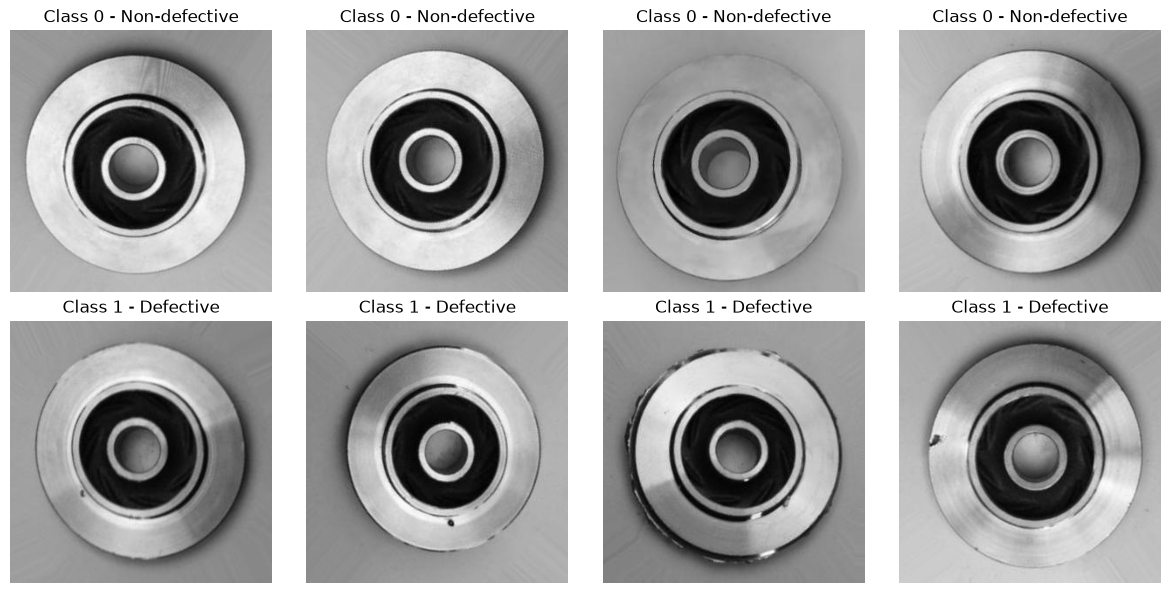

In [7]:
# Display sample images

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):

    # Non-defective
    image = plt.imread(ok_files[i % len(ok_files)])

    axes[0, i].imshow(image)
    axes[0, i].set_title("Class 0 - Non-defective")
    axes[0, i].axis("off")

    # Defective
    image = plt.imread(def_files[i % len(def_files)])

    axes[1, i].imshow(image)
    axes[1, i].set_title("Class 1 - Defective")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [8]:



# CELL 16 — Code

# Main training configuration

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20
EPOCHS = 25

# Explicit class order
# Class 0 = Non-defective
# Class 1 = Defective

CLASS_NAMES = [
    "ok_front",
    "def_front"
]

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Validation split:", VALIDATION_SPLIT)
print("Maximum epochs:", EPOCHS)

print("\nClass Mapping:")
print("Class 0 -> Non-defective")
print("Class 1 -> Defective")

Image size: (224, 224)
Batch size: 32
Validation split: 0.2
Maximum epochs: 25

Class Mapping:
Class 0 -> Non-defective
Class 1 -> Defective


In [9]:
# Load training dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\nTraining dataset loaded.")

Found 80 files belonging to 2 classes.
Using 64 files for training.

Training dataset loaded.


In [10]:
# Load validation dataset

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nValidation dataset loaded.")

Found 80 files belonging to 2 classes.
Using 16 files for validation.

Validation dataset loaded.


In [11]:
# Load test dataset

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nTest dataset loaded.")

print("\nDetected class names:")
print(train_dataset.class_names)

Found 20 files belonging to 2 classes.

Test dataset loaded.

Detected class names:
['ok_front', 'def_front']


In [12]:
# Optimize TensorFlow input pipelines

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Dataset pipelines optimized successfully.")

Dataset pipelines optimized successfully.



---

# CELL 23 — Markdown

```markdown
## 8. Data Augmentation

The following augmentation techniques are used:

- Random horizontal flip
- Random rotation
- Random zoom
- Random contrast

Data augmentation is applied only during training.

It helps the model handle small variations in:

- Product orientation
- Camera position
- Zoom
- Lighting

In [13]:
# Data augmentation

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)

print("Data augmentation created.")

Data augmentation created.


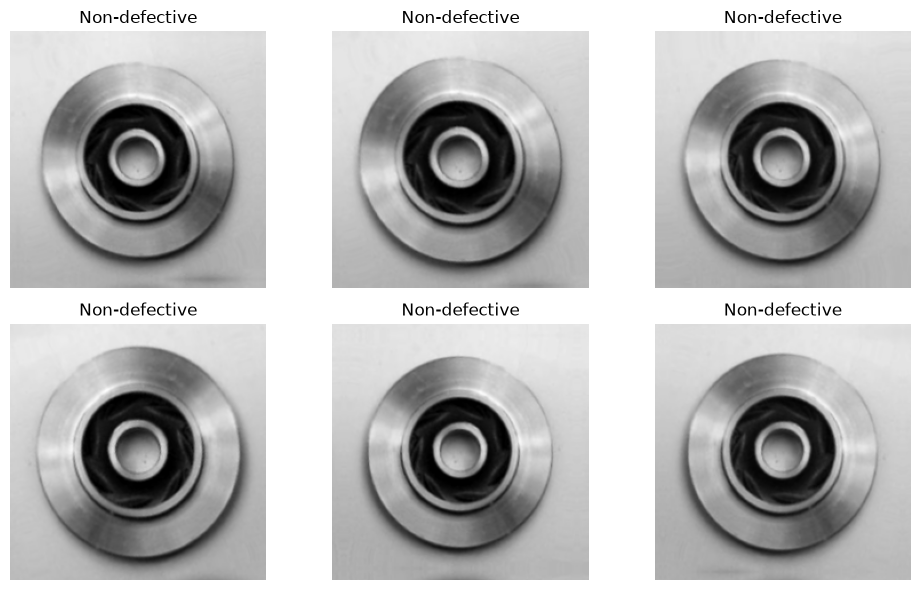

In [14]:
# Visualize data augmentation

for images, labels in train_dataset.take(1):

    sample_image = images[0:1]

    sample_label = int(labels[0].numpy()[0])

    plt.figure(figsize=(10, 6))

    for i in range(6):

        augmented_image = data_augmentation(
            sample_image,
            training=True
        )

        ax = plt.subplot(2, 3, i + 1)

        plt.imshow(
            tf.cast(augmented_image[0], tf.uint8)
        )

        if sample_label == 0:
            plt.title("Non-defective")
        else:
            plt.title("Defective")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

In [15]:



# CELL 27 — Code

# Build CNN model

from tensorflow.keras import layers, models

model = models.Sequential(
    [
        layers.Input(
            shape=(224, 224, 3),
            name="input_image"
        ),

        # Data augmentation
        data_augmentation,

        # Normalization
        layers.Rescaling(
            1.0 / 255,
            name="normalization"
        ),

        # Convolution block 1
        layers.Conv2D(
            32,
            3,
            activation="relu",
            name="conv_32"
        ),

        layers.MaxPooling2D(
            name="pool_32"
        ),

        # Convolution block 2
        layers.Conv2D(
            64,
            3,
            activation="relu",
            name="conv_64"
        ),

        layers.MaxPooling2D(
            name="pool_64"
        ),

        # Convolution block 3
        layers.Conv2D(
            128,
            3,
            activation="relu",
            name="conv_128"
        ),

        layers.MaxPooling2D(
            name="pool_128"
        ),

        # Global average pooling
        layers.GlobalAveragePooling2D(
            name="global_average_pooling"
        ),

        # Dropout
        layers.Dropout(
            0.40,
            name="dropout"
        ),

        # Fully connected layer
        layers.Dense(
            64,
            activation="relu",
            name="dense_64"
        ),

        # Output
        layers.Dense(
            1,
            activation="sigmoid",
            name="output"
        )
    ],
    name="casting_quality_cnn"
)

print("CNN model created successfully.")

CNN model created successfully.


In [16]:
# Display model architecture

model.summary()

Model: "casting_quality_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Rescaling)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32 (Conv2D)                │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_32 (MaxPooling2D)          │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_64 (Conv2D)                │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_64 (MaxPooling2D)          │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_128 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_128 (MaxPooling2D)         │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:



# CELL 30 — Code

# Compile model

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [18]:
# Training callbacks

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [19]:



# CELL 34 — Code

# Train the CNN

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed successfully.")
print("Actual epochs completed:", len(history.history["loss"]))

Epoch 1/25


c:\Users\S_Gayathri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5000 - loss: 0.6960 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.7686 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5000 - loss: 0.6980 - precision: 0.5000 - recall: 0.1250 - val_accuracy: 0.0000e+00 - val_loss: 0.7172 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 979ms/step - accuracy: 0.5156 - loss: 0.6984 - precision: 0.5556 - recall: 0.1562 - val_accuracy: 0.0000e+00 - val_loss: 0.7175 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5156 - loss: 0.6947 - precision: 0.5556 - recall: 0.1562 - val_accuracy: 0.0000e+00 - val_loss: 0.7008 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 

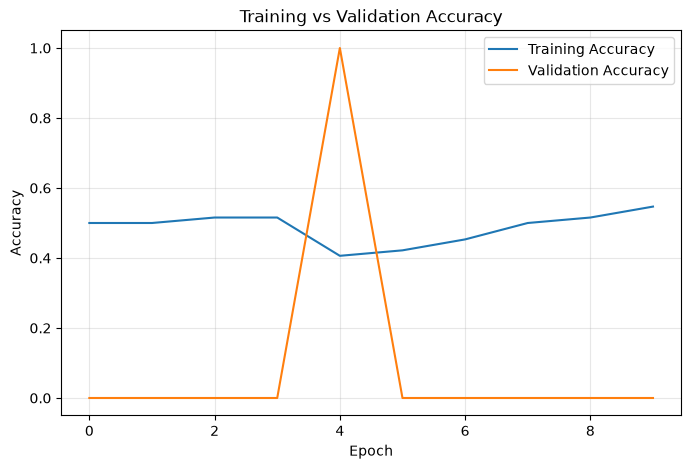

In [20]:
# Plot accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

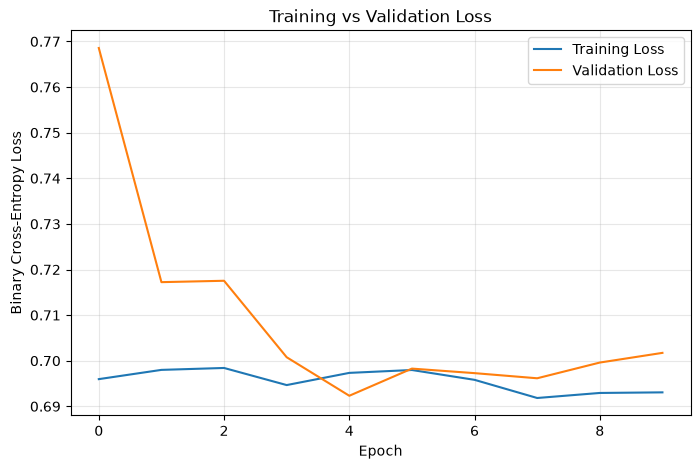

In [21]:
# Plot loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

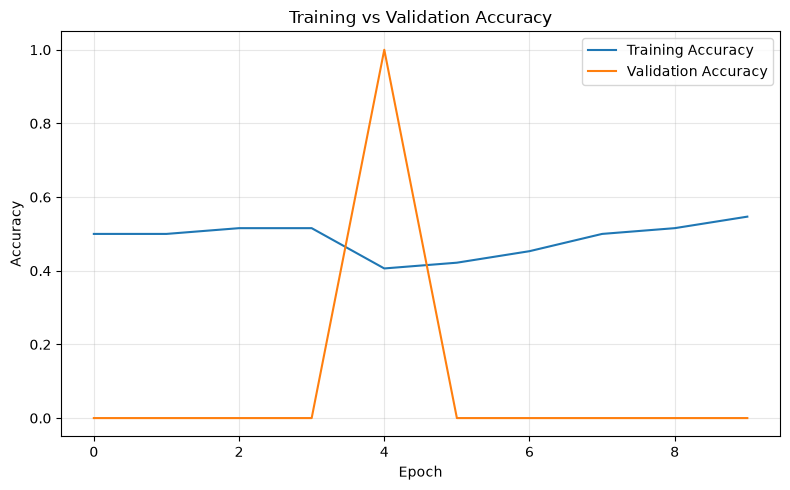

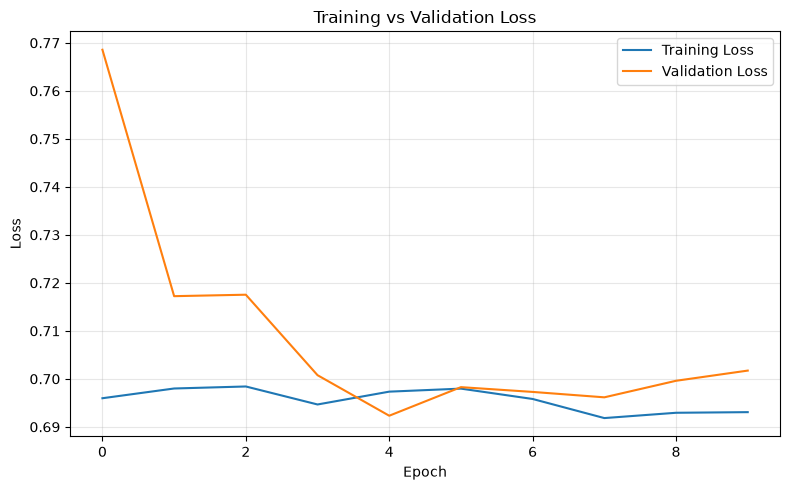

Accuracy graph saved to:
c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\reports\training_validation_accuracy.png

Loss graph saved to:
c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\reports\training_validation_loss.png


In [22]:
# Save training graphs

accuracy_plot_path = REPORT_DIR / "training_validation_accuracy.png"
loss_plot_path = REPORT_DIR / "training_validation_loss.png"

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    accuracy_plot_path,
    dpi=150
)

plt.show()


# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    loss_plot_path,
    dpi=150
)

plt.show()

print("Accuracy graph saved to:")
print(accuracy_plot_path)

print("\nLoss graph saved to:")
print(loss_plot_path)

In [23]:
# Evaluate model on test dataset

test_results = model.evaluate(
    test_dataset,
    return_dict=True,
    verbose=1
)

test_loss = float(test_results["loss"])
test_accuracy = float(test_results["accuracy"])
test_precision = float(test_results["precision"])
test_recall = float(test_results["recall"])

print("\nFINAL TEST RESULTS")
print("=" * 40)

print(
    f"Test Loss      : {test_loss:.4f}"
)

print(
    f"Test Accuracy  : {test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"Test Precision : {test_precision:.4f} "
    f"({test_precision * 100:.2f}%)"
)

print(
    f"Test Recall    : {test_recall:.4f} "
    f"({test_recall * 100:.2f}%)"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5000 - loss: 0.6930 - precision: 0.5000 - recall: 1.0000

FINAL TEST RESULTS
Test Loss      : 0.6930
Test Accuracy  : 0.5000 (50.00%)
Test Precision : 0.5000 (50.00%)
Test Recall    : 1.0000 (100.00%)


In [24]:



# CELL 43 — Code

# Generate predictions for the complete test dataset

actual_labels = []
probabilities = []

for batch_images, batch_labels in test_dataset:

    batch_probabilities = model.predict(
        batch_images,
        verbose=0
    ).ravel()

    probabilities.extend(
        batch_probabilities.tolist()
    )

    actual_labels.extend(
        batch_labels.numpy()
        .ravel()
        .astype(int)
        .tolist()
    )


actual_labels = np.array(
    actual_labels,
    dtype=int
)

probabilities = np.array(
    probabilities,
    dtype=float
)

predictions = (
    probabilities >= 0.50
).astype(int)


print("Total test samples:", len(actual_labels))
print("Predictions generated:", len(predictions))

Total test samples: 20
Predictions generated: 20


Confusion Matrix:
[[ 0 10]
 [ 0 10]]


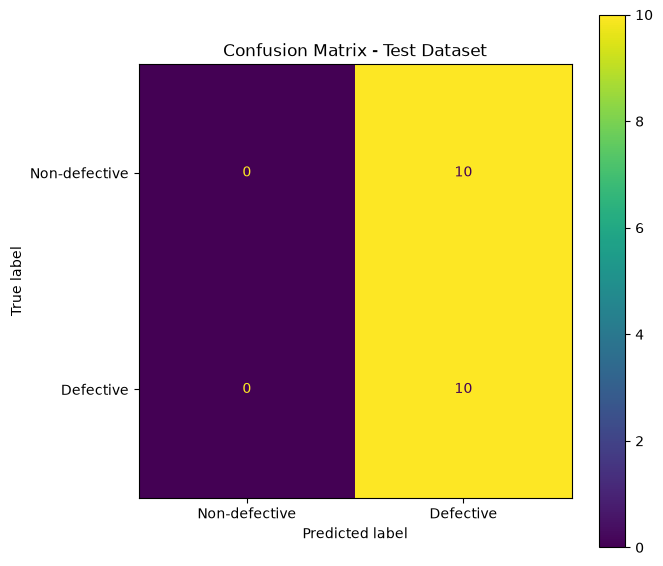

In [25]:



# CELL 45 — Code

# Create confusion matrix

cm = confusion_matrix(
    actual_labels,
    predictions,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-defective",
        "Defective"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

disp.plot(ax=ax)

ax.set_title(
    "Confusion Matrix - Test Dataset"
)

plt.tight_layout()
plt.show()

In [26]:
# Classification report

report = classification_report(
    actual_labels,
    predictions,
    labels=[0, 1],
    target_names=[
        "Non-defective",
        "Defective"
    ],
    digits=4,
    zero_division=0
)

print(report)

               precision    recall  f1-score   support

Non-defective     0.0000    0.0000    0.0000        10
    Defective     0.5000    1.0000    0.6667        10

     accuracy                         0.5000        20
    macro avg     0.2500    0.5000    0.3333        20
 weighted avg     0.2500    0.5000    0.3333        20



In [27]:
# Calculate additional metrics

accuracy = accuracy_score(
    actual_labels,
    predictions
)

precision = precision_score(
    actual_labels,
    predictions,
    zero_division=0
)

recall = recall_score(
    actual_labels,
    predictions,
    zero_division=0
)

tn, fp, fn, tp = cm.ravel()

print("Detailed Metrics")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

print("\nConfusion Matrix Values")
print("=" * 40)

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

Detailed Metrics
Accuracy : 0.5000
Precision: 0.5000
Recall   : 1.0000

Confusion Matrix Values
True Negative : 0
False Positive: 10
False Negative: 0
True Positive : 10


In [28]:
# Select five unseen test images

test_ok_files = get_image_files(
    TEST_DIR / "ok_front"
)

test_def_files = get_image_files(
    TEST_DIR / "def_front"
)

unseen_files = []

# Select up to 3 non-defective images
unseen_files.extend(
    test_ok_files[:3]
)

# Select up to 2 defective images
unseen_files.extend(
    test_def_files[:2]
)

# Fill remaining slots if required
all_test_files = (
    test_ok_files +
    test_def_files
)

for file_path in all_test_files:

    if len(unseen_files) >= 5:
        break

    if file_path not in unseen_files:
        unseen_files.append(file_path)

unseen_files = unseen_files[:5]

print("Selected unseen images:")

for file_path in unseen_files:
    print(file_path.name)

Selected unseen images:
cast_ok_0_10.jpeg
cast_ok_0_14.jpeg
cast_ok_0_16.jpeg
cast_def_0_15.jpeg
cast_def_0_26.jpeg


Image: cast_ok_0_10.jpeg
Actual: Non-defective
Predicted: Defective
Defective Probability: 50.05%
Action: Send for manual inspection
Image: cast_ok_0_14.jpeg
Actual: Non-defective
Predicted: Defective
Defective Probability: 50.02%
Action: Send for manual inspection
Image: cast_ok_0_16.jpeg
Actual: Non-defective
Predicted: Defective
Defective Probability: 50.03%
Action: Send for manual inspection
Image: cast_def_0_15.jpeg
Actual: Defective
Predicted: Defective
Defective Probability: 50.04%
Action: Send for manual inspection
Image: cast_def_0_26.jpeg
Actual: Defective
Predicted: Defective
Defective Probability: 50.06%
Action: Send for manual inspection


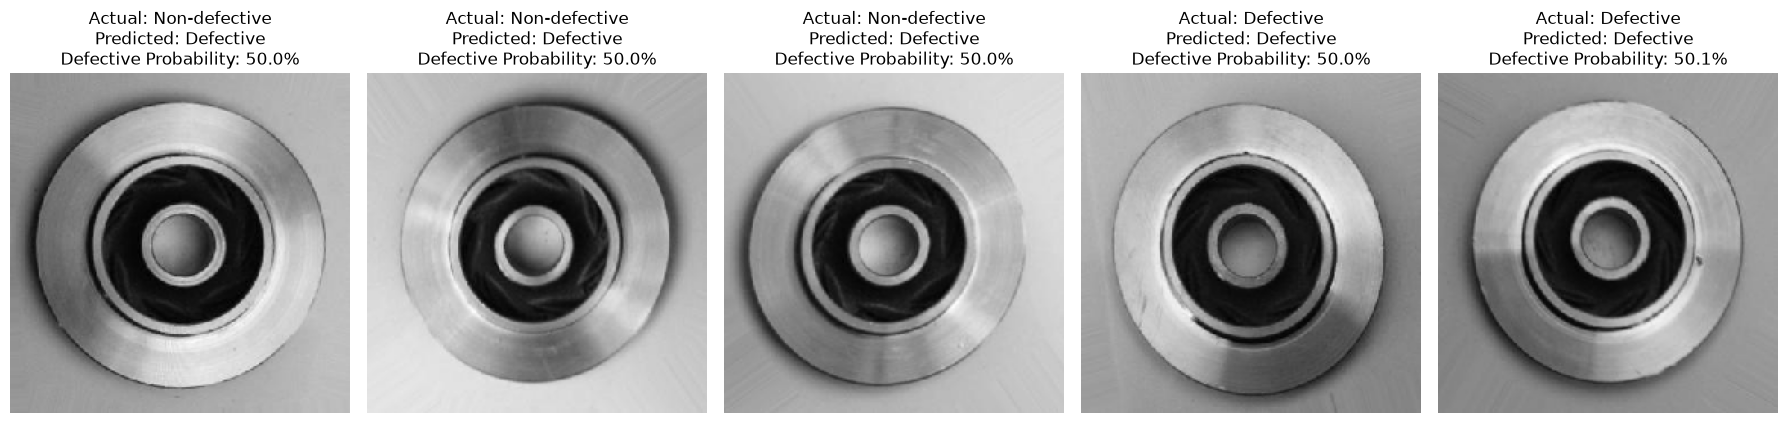

In [29]:
# Predict five unseen images

def load_single_image(path):

    image = tf.keras.utils.load_img(
        path,
        target_size=IMAGE_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    return image_array


fig, axes = plt.subplots(
    1,
    len(unseen_files),
    figsize=(18, 4)
)

if len(unseen_files) == 1:
    axes = [axes]


for ax, image_path in zip(
    axes,
    unseen_files
):

    image_array = load_single_image(
        image_path
    )

    probability = float(
        model.predict(
            np.expand_dims(
                image_array,
                axis=0
            ),
            verbose=0
        )[0][0]
    )

    # Prediction
    predicted_class = (
        1 if probability >= 0.50 else 0
    )

    # Actual class from folder
    actual_class = (
        1
        if image_path.parent.name == "def_front"
        else 0
    )

    predicted_name = (
        "Defective"
        if predicted_class == 1
        else "Non-defective"
    )

    actual_name = (
        "Defective"
        if actual_class == 1
        else "Non-defective"
    )

    if predicted_class == 1:
        action = "Send for manual inspection"
    else:
        action = "Accept as non-defective"


    ax.imshow(
        image_array.astype("uint8")
    )

    ax.set_title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Defective Probability: "
        f"{probability * 100:.1f}%"
    )

    ax.axis("off")


    print("=" * 70)
    print("Image:", image_path.name)
    print("Actual:", actual_name)
    print("Predicted:", predicted_name)
    print(
        f"Defective Probability: "
        f"{probability * 100:.2f}%"
    )
    print("Action:", action)


plt.tight_layout()
plt.show()

In [30]:



# CELL 53 — Code


# Save trained model

MODEL_PATH = MODEL_DIR / "casting_cnn.keras"

model.save(
    MODEL_PATH
)

print("Model saved successfully.")

print("\nModel location:")
print(MODEL_PATH.resolve())

Model saved successfully.

Model location:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\model\casting_cnn.keras


In [31]:
# Verify saved model

loaded_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Saved model loaded successfully.")

loaded_model.summary()

Saved model loaded successfully.


Model: "casting_quality_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Rescaling)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32 (Conv2D)                │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_32 (MaxPooling2D)          │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_64 (Conv2D)                │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_64 (MaxPooling2D)          │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_128 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_128 (MaxPooling2D)         │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,709 (1.16 MB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,140 (793.52 KB)

In [32]:
# Print design decision table

design_decisions = [
    (
        "Image size",
        "224 × 224 × 3",
        "Balances visual detail and computation."
    ),

    (
        "Problem type",
        "Binary classification",
        "There are two classes."
    ),

    (
        "Model type",
        "CNN",
        "Suitable for image classification."
    ),

    (
        "Conv filters",
        "32, 64, 128",
        "Learn increasingly complex features."
    ),

    (
        "Kernel size",
        "3 × 3",
        "Efficient local feature extraction."
    ),

    (
        "Hidden activation",
        "ReLU",
        "Efficient non-linear activation."
    ),

    (
        "Pooling",
        "MaxPooling2D",
        "Reduces feature dimensions."
    ),

    (
        "Global pooling",
        "GlobalAveragePooling2D",
        "Reduces trainable parameters."
    ),

    (
        "Output activation",
        "Sigmoid",
        "Produces binary probability."
    ),

    (
        "Optimizer",
        "Adam",
        "Adaptive and beginner-friendly."
    ),

    (
        "Learning rate",
        "0.001",
        "Reasonable starting value."
    ),

    (
        "Loss",
        "Binary Cross-Entropy",
        "Suitable for binary classification."
    ),

    (
        "Batch size",
        "32",
        "Balances memory and training speed."
    ),

    (
        "Epochs",
        "Maximum 25",
        "Early stopping controls training."
    ),

    (
        "Dropout",
        "0.40",
        "Helps reduce overfitting."
    ),

    (
        "Augmentation",
        "Flip, rotation, zoom, contrast",
        "Improves robustness."
    ),

    (
        "Metrics",
        "Accuracy, Precision, Recall",
        "Evaluate classification performance."
    )
]

print(
    f"{'Design Decision':<22} | "
    f"{'Selected Value':<32} | "
    f"Reason"
)

print("-" * 120)

for decision, value, reason in design_decisions:

    print(
        f"{decision:<22} | "
        f"{value:<32} | "
        f"{reason}"
    )

Design Decision        | Selected Value                   | Reason
------------------------------------------------------------------------------------------------------------------------
Image size             | 224 × 224 × 3                    | Balances visual detail and computation.
Problem type           | Binary classification            | There are two classes.
Model type             | CNN                              | Suitable for image classification.
Conv filters           | 32, 64, 128                      | Learn increasingly complex features.
Kernel size            | 3 × 3                            | Efficient local feature extraction.
Hidden activation      | ReLU                             | Efficient non-linear activation.
Pooling                | MaxPooling2D                     | Reduces feature dimensions.
Global pooling         | GlobalAveragePooling2D           | Reduces trainable parameters.
Output activation      | Sigmoid                          | Produces b

In [33]:
# Generate automatic results summary

best_epoch = int(
    np.argmin(
        history.history["val_loss"]
    ) + 1
)

best_val_loss = float(
    np.min(
        history.history["val_loss"]
    )
)

best_val_accuracy = float(
    np.max(
        history.history["val_accuracy"]
    )
)


results_summary = f"""
TASK 14 - CNN RESULTS SUMMARY

Dataset:
Casting Product Image Data for Quality Inspection

Class 0:
Non-defective (ok_front)

Class 1:
Defective (def_front)

Input size:
224 × 224 × 3

Batch size:
32

Maximum epochs:
25

Actual epochs:
{len(history.history["loss"])}

Best validation-loss epoch:
{best_epoch}

Best validation loss:
{best_val_loss:.4f}

Best validation accuracy:
{best_val_accuracy:.4f}

Test accuracy:
{test_accuracy:.4f}

Test precision:
{test_precision:.4f}

Test recall:
{test_recall:.4f}

Confusion Matrix:

TN = {tn}
FP = {fp}
FN = {fn}
TP = {tp}

Model:
{MODEL_PATH}
"""


print(results_summary)


SUMMARY_PATH = REPORT_DIR / "results_summary.txt"

SUMMARY_PATH.write_text(
    results_summary,
    encoding="utf-8"
)

print("\nResults summary saved to:")
print(SUMMARY_PATH.resolve())


TASK 14 - CNN RESULTS SUMMARY

Dataset:
Casting Product Image Data for Quality Inspection

Class 0:
Non-defective (ok_front)

Class 1:
Defective (def_front)

Input size:
224 × 224 × 3

Batch size:
32

Maximum epochs:
25

Actual epochs:
10

Best validation-loss epoch:
5

Best validation loss:
0.6923

Best validation accuracy:
1.0000

Test accuracy:
0.5000

Test precision:
0.5000

Test recall:
1.0000

Confusion Matrix:

TN = 0
FP = 10
FN = 0
TP = 10

Model:
c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\model\casting_cnn.keras


Results summary saved to:
C:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 14 - Neural Network Implementation with Documented Design Choices\S.GayathriG40-AIML\reports\results_summary.txt


## 23. Optional Bonus Experiment

The task allows changing **one design choice** and comparing the results.

For this experiment:

### Original Design

```text
Dropout = 0.40

Dropout = 0.20

In [34]:
RUN_BONUS_EXPERIMENT = True

In [39]:



# CELL 60 — Code

# Optional bonus experiment
# Change Dropout from 0.40 to 0.20

RUN_BONUS_EXPERIMENT = True


if RUN_BONUS_EXPERIMENT:

    bonus_model = models.Sequential(
        [

            layers.Input(
                shape=(224, 224, 3)
            ),

            data_augmentation,

            layers.Rescaling(
                1.0 / 255
            ),

            layers.Conv2D(
                32,
                3,
                activation="relu"
            ),

            layers.MaxPooling2D(),

            layers.Conv2D(
                64,
                3,
                activation="relu"
            ),

            layers.MaxPooling2D(),

            layers.Conv2D(
                128,
                3,
                activation="relu"
            ),

            layers.MaxPooling2D(),

            layers.GlobalAveragePooling2D(),

            # Changed from 0.40 to 0.20
            layers.Dropout(0.20),

            layers.Dense(
                64,
                activation="relu"
            ),

            layers.Dense(
                1,
                activation="sigmoid"
            )
        ],

        name="bonus_cnn_dropout_020"
    )


    bonus_model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="binary_crossentropy",

        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),

            tf.keras.metrics.Precision(
                name="precision"
            ),

            tf.keras.metrics.Recall(
                name="recall"
            )
        ]
    )


    bonus_history = bonus_model.fit(

        train_dataset,

        validation_data=validation_dataset,

        epochs=25,

        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
                verbose=1
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=1
            )
        ],

        verbose=1
    )


    bonus_results = bonus_model.evaluate(
        test_dataset,
        return_dict=True,
        verbose=1
    )


    print("\nBONUS EXPERIMENT RESULTS")
    print("=" * 50)

    print("Original Design: Dropout = 0.40")
    print("Changed Design: Dropout = 0.20")

    print(
        "\nOriginal Test Accuracy:",
        f"{test_accuracy:.4f}"
    )

    print(
        "New Test Accuracy:",
        f"{bonus_results['accuracy']:.4f}"
    )

    print(
        "\nOriginal Test Recall:",
        f"{test_recall:.4f}"
    )

    print(
        "New Test Recall:",
        f"{bonus_results['recall']:.4f}"
    )

else:

    print(
        "Bonus experiment is disabled."
    )

    print(
        "Set RUN_BONUS_EXPERIMENT = True "
        "to run the experiment."
    )

Epoch 1/25


c:\Users\S_Gayathri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5000 - loss: 0.6919 - precision: 0.5000 - recall: 0.4688 - val_accuracy: 0.0000e+00 - val_loss: 0.7581 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5000 - loss: 0.6995 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.7841 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 996ms/step - accuracy: 0.5156 - loss: 0.6882 - precision: 1.0000 - recall: 0.0312 - val_accuracy: 0.0000e+00 - val_loss: 0.7289 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5312 - loss: 0.6943 - precision: 0.5417 - recall: 0.4062 - val_accuracy: 1.0000 - val_loss: 0.6810 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step -

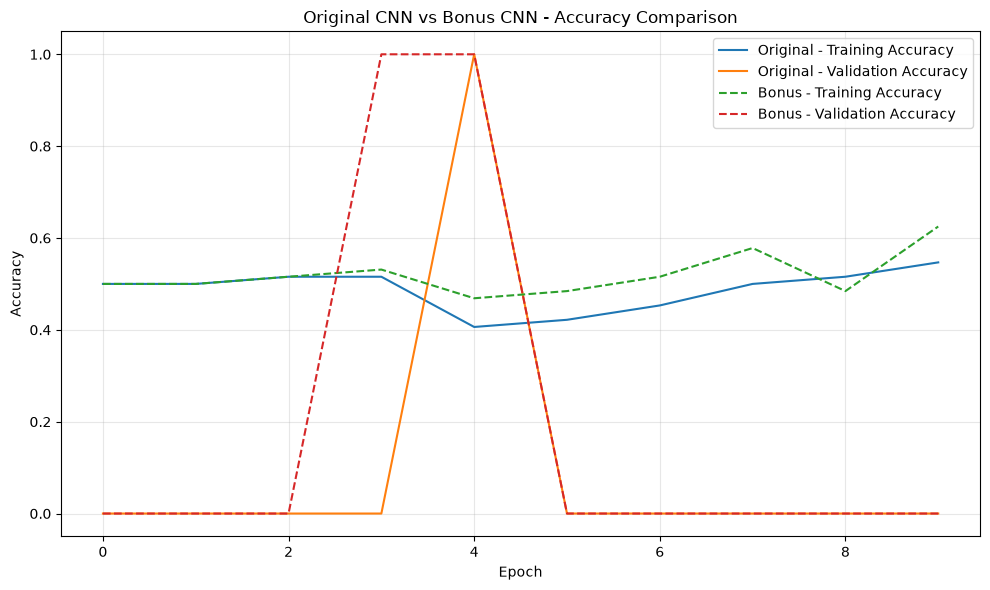

In [40]:
# ============================================
# ORIGINAL vs BONUS MODEL - ACCURACY
# ============================================

plt.figure(figsize=(10, 6))

# Original model
plt.plot(
    history.history["accuracy"],
    label="Original - Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Original - Validation Accuracy"
)

# Bonus model
plt.plot(
    bonus_history.history["accuracy"],
    linestyle="--",
    label="Bonus - Training Accuracy"
)

plt.plot(
    bonus_history.history["val_accuracy"],
    linestyle="--",
    label="Bonus - Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Original CNN vs Bonus CNN - Accuracy Comparison")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

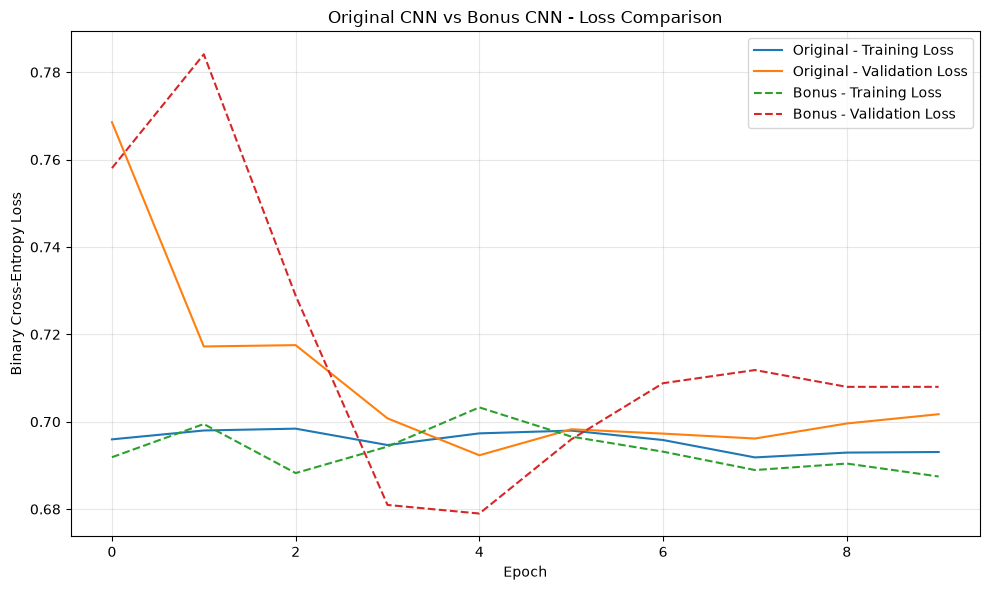

In [41]:
# ============================================
# ORIGINAL vs BONUS MODEL - LOSS
# ============================================

plt.figure(figsize=(10, 6))

# Original model
plt.plot(
    history.history["loss"],
    label="Original - Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Original - Validation Loss"
)

# Bonus model
plt.plot(
    bonus_history.history["loss"],
    linestyle="--",
    label="Bonus - Training Loss"
)

plt.plot(
    bonus_history.history["val_loss"],
    linestyle="--",
    label="Bonus - Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Original CNN vs Bonus CNN - Loss Comparison")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

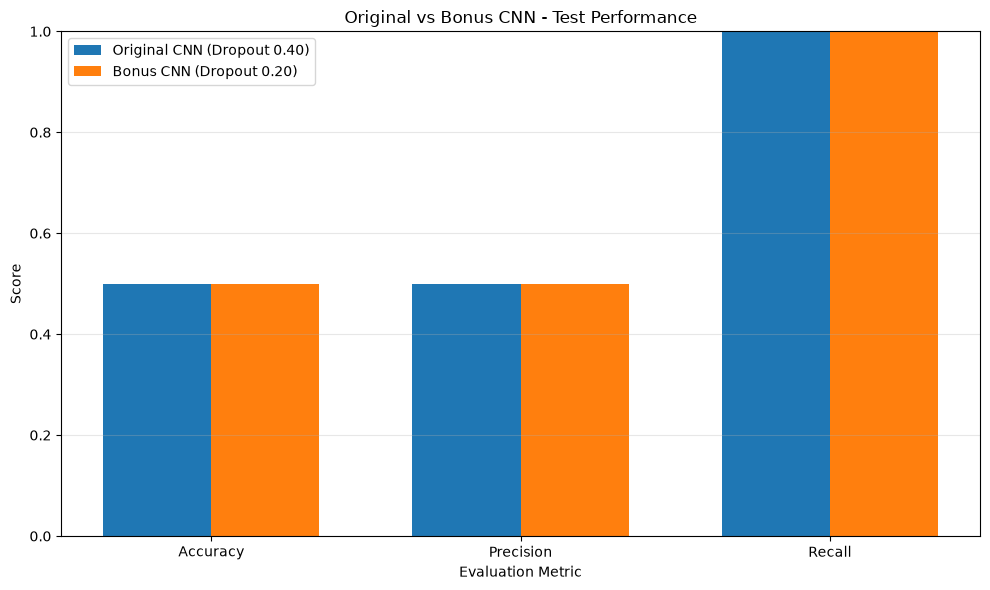

In [42]:
# ============================================
# FINAL TEST METRICS COMPARISON
# ============================================

original_accuracy = test_results["accuracy"]
original_precision = test_results["precision"]
original_recall = test_results["recall"]

bonus_accuracy = bonus_results["accuracy"]
bonus_precision = bonus_results["precision"]
bonus_recall = bonus_results["recall"]


metrics = [
    "Accuracy",
    "Precision",
    "Recall"
]

original_values = [
    original_accuracy,
    original_precision,
    original_recall
]

bonus_values = [
    bonus_accuracy,
    bonus_precision,
    bonus_recall
]


x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    original_values,
    width,
    label="Original CNN (Dropout 0.40)"
)

plt.bar(
    x + width / 2,
    bonus_values,
    width,
    label="Bonus CNN (Dropout 0.20)"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Original vs Bonus CNN - Test Performance")

plt.xticks(
    x,
    metrics
)

plt.ylim(0, 1.0)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

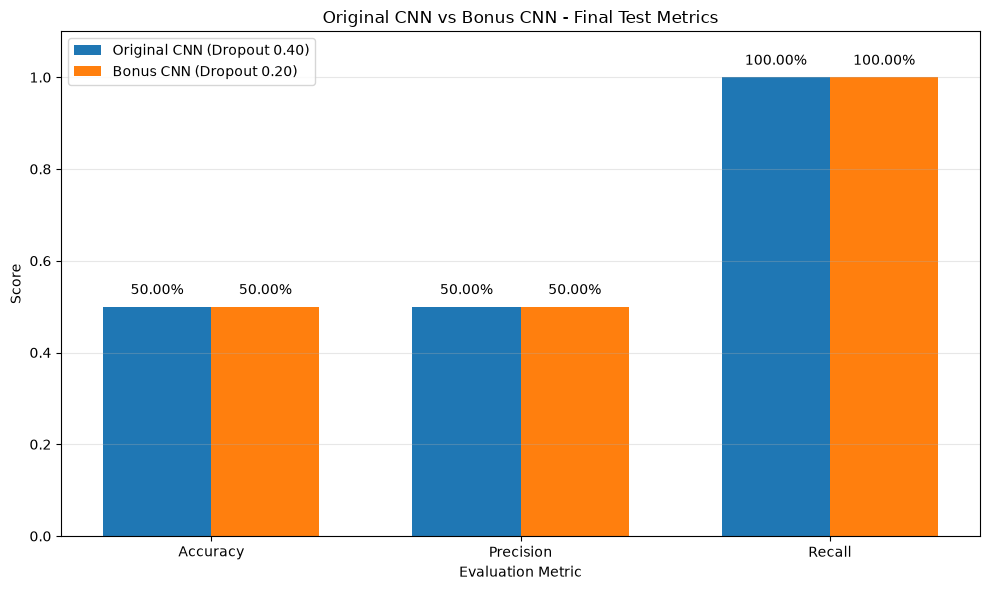

In [43]:
# ============================================
# TEST METRIC COMPARISON WITH VALUES
# ============================================

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    original_values,
    width,
    label="Original CNN (Dropout 0.40)"
)

bars2 = plt.bar(
    x + width / 2,
    bonus_values,
    width,
    label="Bonus CNN (Dropout 0.20)"
)


# Add values above bars
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height * 100:.2f}%",
            ha="center",
            va="bottom"
        )


plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.title(
    "Original CNN vs Bonus CNN - Final Test Metrics"
)

plt.xticks(
    x,
    metrics
)

plt.ylim(0, 1.1)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [44]:
# ============================================
# ORIGINAL vs BONUS COMPARISON TABLE
# ============================================

print("=" * 75)
print("ORIGINAL CNN vs BONUS CNN")
print("=" * 75)

print(
    f"{'Metric':<15}"
    f"{'Original (0.40)':<25}"
    f"{'Bonus (0.20)':<20}"
    f"{'Change':<15}"
)

print("-" * 75)

for metric, original, bonus in zip(
    metrics,
    original_values,
    bonus_values
):

    change = bonus - original

    print(
        f"{metric:<15}"
        f"{original * 100:>8.2f}%{'':<16}"
        f"{bonus * 100:>8.2f}%{'':<12}"
        f"{change * 100:+.2f}%"
    )

print("=" * 75)

ORIGINAL CNN vs BONUS CNN
Metric         Original (0.40)          Bonus (0.20)        Change         
---------------------------------------------------------------------------
Accuracy          50.00%                   50.00%            +0.00%
Precision         50.00%                   50.00%            +0.00%
Recall           100.00%                  100.00%            +0.00%


In [45]:
# ============================================
# AUTOMATIC BONUS EXPERIMENT CONCLUSION
# ============================================

accuracy_change = bonus_accuracy - original_accuracy
recall_change = bonus_recall - original_recall

print("BONUS EXPERIMENT CONCLUSION")
print("=" * 60)

print(
    f"Original Accuracy : "
    f"{original_accuracy * 100:.2f}%"
)

print(
    f"Bonus Accuracy    : "
    f"{bonus_accuracy * 100:.2f}%"
)

print(
    f"Accuracy Change   : "
    f"{accuracy_change * 100:+.2f}%"
)

print()

print(
    f"Original Recall   : "
    f"{original_recall * 100:.2f}%"
)

print(
    f"Bonus Recall      : "
    f"{bonus_recall * 100:.2f}%"
)

print(
    f"Recall Change     : "
    f"{recall_change * 100:+.2f}%"
)

print("\nInterpretation:")

if accuracy_change > 0 and recall_change > 0:

    print(
        "The bonus model improved both accuracy and recall."
    )

elif accuracy_change < 0 and recall_change < 0:

    print(
        "The original model performed better in both "
        "accuracy and recall."
    )

else:

    print(
        "The two models show a trade-off between "
        "accuracy and recall. Consider the quality-inspection "
        "requirement when selecting the final model."
    )

BONUS EXPERIMENT CONCLUSION
Original Accuracy : 50.00%
Bonus Accuracy    : 50.00%
Accuracy Change   : +0.00%

Original Recall   : 100.00%
Bonus Recall      : 100.00%
Recall Change     : +0.00%

Interpretation:
The two models show a trade-off between accuracy and recall. Consider the quality-inspection requirement when selecting the final model.
